In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [3]:
model=load_model('../models/best_model.keras')
scaler=joblib.load('../models/scaler.pkl')

In [4]:
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')
print('Model and data loaded')

Model and data loaded


In [5]:
## Predict
predictions_scaled = model.predict(X_test)

#convert to real dollar values
predictions =  scaler.inverse_transform(predictions_scaled)
actual= scaler.inverse_transform(y_test.reshape(-1,1))

print("First 5 predicted price: ",predictions[:5].flatten())
print("First 5 actual prices: ",actual[:5].flatten())

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
First 5 predicted price:  [128.81004 129.87831 130.77036 131.73146 132.94655]
First 5 actual prices:  [133.07597351 133.13502502 135.69400024 138.88287354 140.28048706]


In [6]:
mae = mean_absolute_error(actual , predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = np.mean(np.abs((actual-predictions)/actual))*100

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: ${mape:.2f}%")

MAE: $5.14
RMSE: $5.87
MAPE: $2.96%


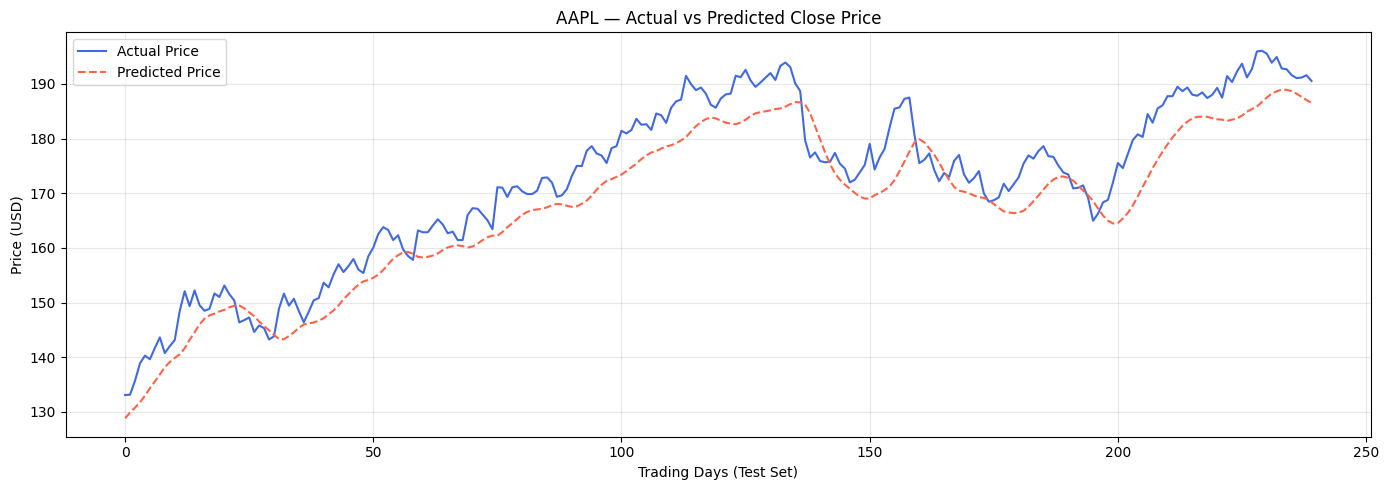

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(actual,      label='Actual Price',    color='royalblue', linewidth=1.5)
plt.plot(predictions, label='Predicted Price', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('AAPL — Actual vs Predicted Close Price')
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


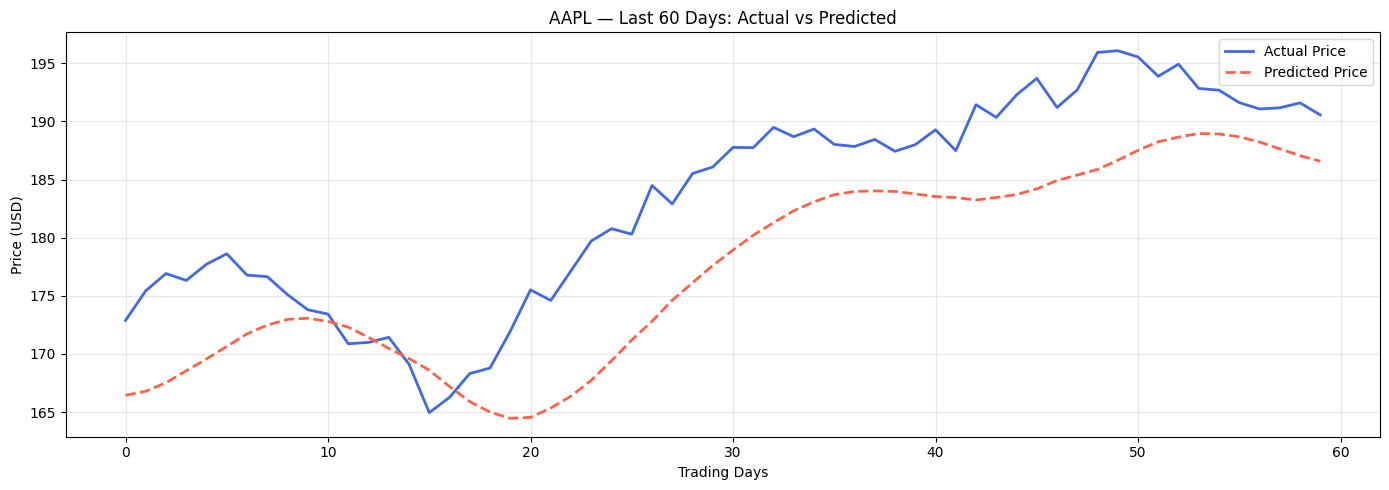

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(actual[-60:],      label='Actual Price',    color='royalblue', linewidth=2)
plt.plot(predictions[-60:], label='Predicted Price', color='tomato',    linewidth=2, linestyle='--')
plt.title('AAPL — Last 60 Days: Actual vs Predicted')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
results_df = pd.DataFrame({
  'Actual': actual.flatten(),
  'Predicted':predictions.flatten()
})
results_df.to_csv('../data/predictions.csv',index=False)
print('Prediction saved')

Prediction saved
